https://www.kaggle.com/datasets/shivam2503/diamonds?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import combinations
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
df = pd.read_csv("../data/diamonds.csv")

df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
df = df.drop(columns=["Unnamed: 0"])
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
df = df.rename(columns={
    "x": "length_mm",
    "y": "width_mm",
    "z": "depth_mm"
})

df.head()

,carat,cut,color,clarity,depth,table,price,length_mm,width_mm,depth_mm
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
print("Cut values:")
print(df["cut"].unique())

print("\nColor values:")
print(df["color"].unique())

print("\nClarity values:")
print(df["clarity"].unique())

Cut values:
['Ideal' 'Premium' 'Good' 'Very Good' 'Fair']

Color values:
['E' 'I' 'J' 'H' 'F' 'G' 'D']

Clarity values:
['SI2' 'SI1' 'VS1' 'VS2' 'VVS2' 'VVS1' 'I1' 'IF']


In [6]:
# Lowest quality to highest quality
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]

# Lowest color grade to highest color grade
# D is best / most colorless, J is lowest in this dataset
color_order = ["J", "I", "H", "G", "F", "E", "D"]

# Lowest clarity to highest clarity
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

df["cut"] = pd.Categorical(df["cut"], categories=cut_order, ordered=True)
df["color"] = pd.Categorical(df["color"], categories=color_order, ordered=True)
df["clarity"] = pd.Categorical(df["clarity"], categories=clarity_order, ordered=True)

In [7]:
print(df["cut"].cat.categories)
print(df["color"].cat.categories)
print(df["clarity"].cat.categories)

Index(['Fair', 'Good', 'Very Good', 'Premium', 'Ideal'], dtype='object')
Index(['J', 'I', 'H', 'G', 'F', 'E', 'D'], dtype='object')
Index(['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF'], dtype='object')


In [8]:
df.head(10)

,carat,cut,color,clarity,depth,table,price,length_mm,width_mm,depth_mm
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


# Does diamond price differ by cut quality? 

In [9]:
df.groupby("cut")["price"].agg(["count", "mean", "median", "std"]).round(2)

C:\Users\zirad\AppData\Local\Temp\ipykernel_19496\1626121021.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("cut")["price"].agg(["count", "mean", "median", "std"]).round(2)


,count,mean,median,std
cut,,,,
Fair,1610,4358.76,3282.0,3560.39
Good,4906,3928.86,3050.5,3681.59
Very Good,12082,3981.76,2648.0,3935.86
Premium,13791,4584.26,3185.0,4349.20
Ideal,21551,3457.54,1810.0,3808.40


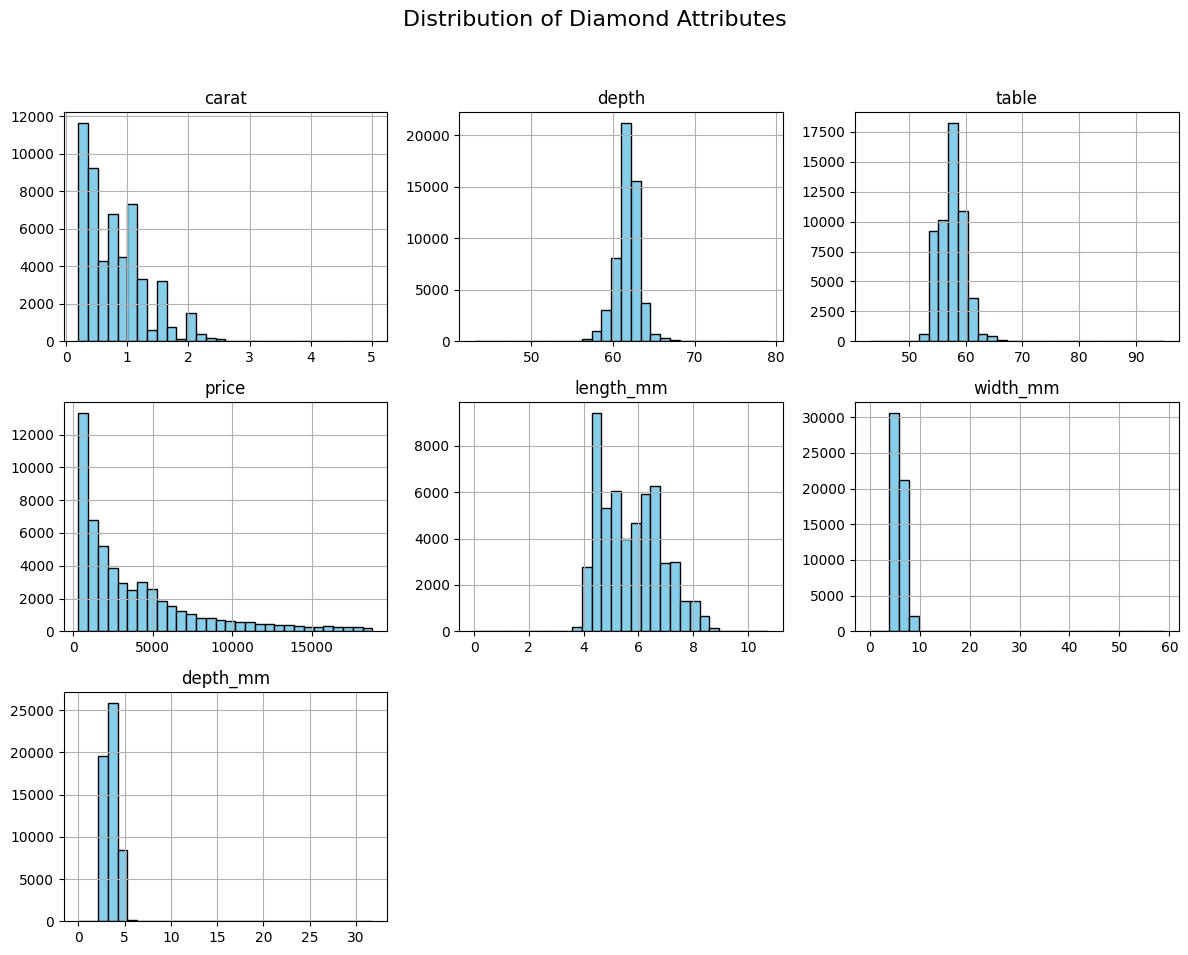

In [10]:
df.hist(figsize=(12, 10), bins=30, color='skyblue', edgecolor='black')

plt.suptitle("Distribution of Diamond Attributes", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Price skewness: 1.618395283383529


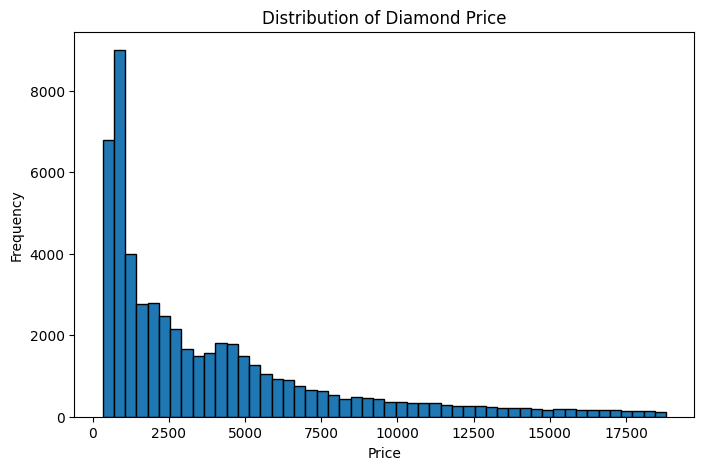

In [11]:
print("Price skewness:", df["price"].skew())

plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=50, edgecolor="black")
plt.title("Distribution of Diamond Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [12]:
cut_groups = []

for cut_level in df["cut"].cat.categories:
    values = df[df["cut"] == cut_level]["price"]
    cut_groups.append(values)
    
    print(cut_level)
    print("n:", len(values))
    print("mean:", round(values.mean(), 2))
    print("median:", round(values.median(), 2))
    print()

Fair
n: 1610
mean: 4358.76
median: 3282.0

Good
n: 4906
mean: 3928.86
median: 3050.5

Very Good
n: 12082
mean: 3981.76
median: 2648.0

Premium
n: 13791
mean: 4584.26
median: 3185.0

Ideal
n: 21551
mean: 3457.54
median: 1810.0



In [13]:
kruskal_cut = stats.kruskal(*cut_groups)

print("Kruskal-Wallis H-statistic:", kruskal_cut.statistic)
print("p-value:", kruskal_cut.pvalue)

Kruskal-Wallis H-statistic: 978.6208219359503
p-value: 1.533414952159139e-210


In [14]:
def epsilon_squared_kruskal(H, n, k):
    return max(0, (H - k + 1) / (n - k))

eps2_cut = epsilon_squared_kruskal(
    H=kruskal_cut.statistic,
    n=len(df),
    k=len(df["cut"].cat.categories)
)

print("Epsilon-squared:", eps2_cut)

Epsilon-squared: 0.018070285008546405


In [15]:
! pip install scikit_posthocs


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import scikit_posthocs as sp

dunn_cut = sp.posthoc_dunn(
    df,
    val_col="price",
    group_col="cut",
    p_adjust="holm"
)

dunn_cut

,Fair,Good,Very Good,Premium,Ideal
Fair,1.000000e+00,2.145274e-18,1.534165e-29,2.411299e-08,1.280918e-68
Good,2.145274e-18,1.000000e+00,5.101482e-03,6.204526e-10,1.028595e-35
Very Good,1.534165e-29,5.101482e-03,1.000000e+00,6.611885e-34,4.491917e-40
Premium,2.411299e-08,6.204526e-10,6.611885e-34,1.000000e+00,1.259098e-171
Ideal,1.280918e-68,1.028595e-35,4.491917e-40,1.259098e-171,1.000000e+00


In [17]:
significant_pairs = []

for i in dunn_cut.index:
    for j in dunn_cut.columns:
        if i < j:
            p_value = dunn_cut.loc[i, j]
            
            if p_value < 0.05:
                significant_pairs.append({
                    "group_1": i,
                    "group_2": j,
                    "holm_adjusted_p": p_value
                })

significant_dunn_cut = pd.DataFrame(significant_pairs)

significant_dunn_cut

,group_1,group_2,holm_adjusted_p
0,Fair,Good,2.145274e-18
1,Fair,Very Good,1.534165e-29
2,Fair,Premium,2.411299e-08
3,Fair,Ideal,1.280918e-68
4,Good,Very Good,5.101482e-03
5,Good,Premium,6.204526e-10
6,Good,Ideal,1.028595e-35
7,Premium,Very Good,6.611885e-34
8,Ideal,Very Good,4.491917e-40
9,Ideal,Premium,1.259098e-171


Diamond prices are different across cut-quality groups, but cut alone does not explain price very strongly.

Even though every cut group differs statistically, the effect size is small. This is likely because diamond price is heavily influenced by other factors, especially carat weight, clarity, color, and physical dimensions.

So the business takeaway is: cut quality matters, but pricing decisions should not be based on cut alone. A larger diamond with a lower cut grade can still cost more than a smaller diamond with an Ideal cut.

In [18]:
df.to_csv("diamonds_tableau.csv", index=False)

df.head()

,carat,cut,color,clarity,depth,table,price,length_mm,width_mm,depth_mm
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


# Does diamond price differ by clarity grade?

In [19]:
clarity_summary = df.groupby("clarity")["price"].agg(
    ["count", "mean", "median", "std"]
).round(2)

clarity_summary

C:\Users\zirad\AppData\Local\Temp\ipykernel_19496\768301712.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clarity_summary = df.groupby("clarity")["price"].agg(


,count,mean,median,std
clarity,,,,
I1,741,3924.17,3344.0,2806.78
SI2,9194,5063.03,4072.0,4260.46
SI1,13065,3996.00,2822.0,3799.48
VS2,12258,3924.99,2054.0,4042.30
VS1,8171,3839.46,2005.0,4011.75
VVS2,5066,3283.74,1311.0,3821.65
VVS1,3655,2523.11,1093.0,3334.84
IF,1790,2864.84,1080.0,3920.25


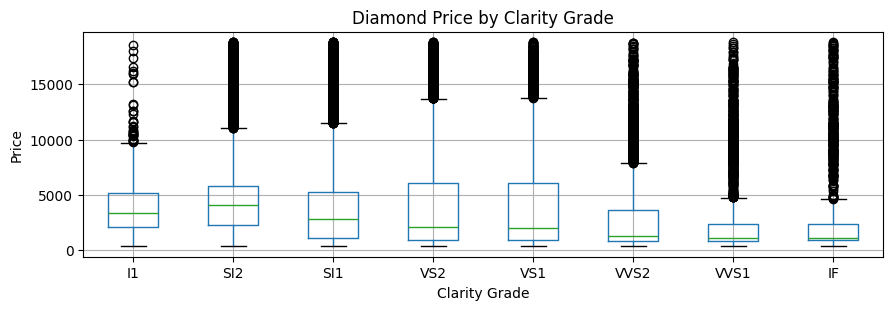

In [20]:
df.boxplot(column="price", by="clarity", figsize=(10, 3))

plt.title("Diamond Price by Clarity Grade")
plt.suptitle("")
plt.xlabel("Clarity Grade")
plt.ylabel("Price")
plt.show()

In [21]:
clarity_groups = []

for clarity_level in df["clarity"].cat.categories:
    values = df[df["clarity"] == clarity_level]["price"]
    clarity_groups.append(values)
    
    print(clarity_level)
    print("n:", len(values))
    print("mean:", round(values.mean(), 2))
    print("median:", round(values.median(), 2))
    print()

I1
n: 741
mean: 3924.17
median: 3344.0

SI2
n: 9194
mean: 5063.03
median: 4072.0

SI1
n: 13065
mean: 3996.0
median: 2822.0

VS2
n: 12258
mean: 3924.99
median: 2054.0

VS1
n: 8171
mean: 3839.46
median: 2005.0

VVS2
n: 5066
mean: 3283.74
median: 1311.0

VVS1
n: 3655
mean: 2523.11
median: 1093.0

IF
n: 1790
mean: 2864.84
median: 1080.0



In [22]:
kruskal_clarity = stats.kruskal(*clarity_groups)

print("Kruskal-Wallis H-statistic:", kruskal_clarity.statistic)
print("p-value:", kruskal_clarity.pvalue)

Kruskal-Wallis H-statistic: 2718.1865426181407
p-value: 0.0


In [23]:
import scikit_posthocs as sp

dunn_clarity = sp.posthoc_dunn(
    df,
    val_col="price",
    group_col="clarity",
    p_adjust="holm"
)

dunn_clarity

,I1,SI2,SI1,VS2,VS1,VVS2,VVS1,IF
I1,1.000000e+00,5.704694e-03,1.856464e-06,1.228184e-12,1.262988e-15,1.489101e-37,1.127590e-67,3.821896e-44
SI2,5.704694e-03,1.000000e+00,5.504179e-112,1.483779e-178,1.260151e-176,3.219304e-280,0.000000e+00,7.149757e-176
SI1,1.856464e-06,5.504179e-112,1.000000e+00,3.215222e-11,9.206144e-18,8.962510e-82,2.235639e-165,1.095055e-62
VS2,1.228184e-12,1.483779e-178,3.215222e-11,1.000000e+00,8.019006e-03,5.424697e-43,5.637411e-113,1.030948e-39
VS1,1.262988e-15,1.260151e-176,9.206144e-18,8.019006e-03,1.000000e+00,1.227931e-26,2.125085e-84,1.153880e-29
VVS2,1.489101e-37,3.219304e-280,8.962510e-82,5.424697e-43,1.227931e-26,1.000000e+00,2.150761e-18,4.729101e-04
VVS1,1.127590e-67,0.000000e+00,2.235639e-165,5.637411e-113,2.125085e-84,2.150761e-18,1.000000e+00,5.704694e-03
IF,3.821896e-44,7.149757e-176,1.095055e-62,1.030948e-39,1.153880e-29,4.729101e-04,5.704694e-03,1.000000e+00


In [24]:
significant_pairs = []

for i in dunn_clarity.index:
    for j in dunn_clarity.columns:
        if i < j:
            p_value = dunn_clarity.loc[i, j]
            
            if p_value < 0.05:
                significant_pairs.append({
                    "group_1": i,
                    "group_2": j,
                    "holm_adjusted_p": p_value
                })

significant_dunn_clarity = pd.DataFrame(significant_pairs)

significant_dunn_clarity

,group_1,group_2,holm_adjusted_p
0,I1,SI2,5.704694e-03
1,I1,SI1,1.856464e-06
2,I1,VS2,1.228184e-12
3,I1,VS1,1.262988e-15
4,I1,VVS2,1.489101e-37
5,I1,VVS1,1.127590e-67
6,I1,IF,3.821896e-44
7,SI2,VS2,1.483779e-178
8,SI2,VS1,1.260151e-176
9,SI2,VVS2,3.219304e-280


In [25]:
def epsilon_squared_kruskal(H, n, k):
    return max(0, (H - k + 1) / (n - k))

eps2_clarity = epsilon_squared_kruskal(
    H=kruskal_clarity.statistic,
    n=len(df),
    k=len(df["clarity"].cat.categories)
)

print("Epsilon-squared:", eps2_clarity)

Epsilon-squared: 0.050270461741046886
